<a href="https://colab.research.google.com/github/wilmar-barragan/Deep-Learning-week4-actividad_3-Aplicaci-n-de-T-cnicas-de-Optimizaci-n-en-una-Red-Neuronal./blob/main/Aplicaci%C3%B3n%20de%20T%C3%A9cnicas%20de%20Optimizaci%C3%B3n%20en%20una%20Red%20Neuronal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Optimización en el Entrenamiento de Redes Neuronales
**Objetivo:** Comprender cómo varía el proceso de aprendizaje al modificar la regla de actualización de parámetros. Se comparan dos optimizadores (SGD vs Adam) manteniendo constantes el modelo, los datos, la tasa de aprendizaje y el número de épocas, garantizando una comparación válida y reproducible.

In [1]:
#(Configuración, Semillas y Dispositivo)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import random

# Reproducibilidad total
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔹 Dispositivo: {device}")

🔹 Dispositivo: cpu


In [2]:
#(Carga de Datos)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # Normalización MNIST
])

train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST('./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=1000, shuffle=False, num_workers=2)
print("✅ Datasets MNIST cargados correctamente.")

100%|██████████| 9.91M/9.91M [00:00<00:00, 57.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.70MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.6MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.56MB/s]

✅ Datasets MNIST cargados correctamente.


In [3]:

#(Definición del Modelo Base)
class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        return self.fc3(x)  # Sin softmax: CrossEntropyLoss ya la incluye internamente

print("🔹 Arquitectura del modelo definida.")

🔹 Arquitectura del modelo definida.


In [5]:
#(Función de Entrenamiento por Épocas)
def train_epoch_loop(model, optimizer, criterion, train_loader, test_loader, epochs=15):
    model.to(device)
    history = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}

    for epoch in range(epochs):
        # Entrenamiento
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            _, preds = outputs.max(1)
            total += targets.size(0)
            correct += preds.eq(targets).sum().item()

        history["train_loss"].append(running_loss / total)
        history["train_acc"].append(100. * correct / total)

        # Validación
        model.eval()
        test_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, targets in test_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                test_loss += loss.item() * inputs.size(0)
                _, preds = outputs.max(1)
                total += targets.size(0)
                correct += preds.eq(targets).sum().item()

        history["test_loss"].append(test_loss / total)
        history["test_acc"].append(100. * correct / total)
        print(f"  Época {epoch+1:2d}/{epochs} | Train Loss: {history['train_loss'][-1]:.4f} | Train Acc: {history['train_acc'][-1]:.2f}% | "
              f"Test Loss: {history['test_loss'][-1]:.4f} | Test Acc: {history['test_acc'][-1]:.2f}%")
    return history

In [6]:
#(Comparación de Configuraciones)
criterion = nn.CrossEntropyLoss()
EPOCHS = 15
LR = 0.01  # Se mantiene constante para aislar el efecto del optimizador

print("="*60)
print("🔹 CONFIGURACIÓN 1: SGD (lr=0.01, momentum=0.9)")
print("="*60)
set_seed()
model_sgd = SimpleNet()
optimizer_sgd = optim.SGD(model_sgd.parameters(), lr=LR, momentum=0.9)
history_sgd = train_epoch_loop(model_sgd, optimizer_sgd, criterion, train_loader, test_loader, EPOCHS)

print("\n" + "="*60)
print("🔹 CONFIGURACIÓN 2: Adam (lr=0.01)")
print("="*60)
set_seed()
model_adam = SimpleNet()
optimizer_adam = optim.Adam(model_adam.parameters(), lr=LR)
history_adam = train_epoch_loop(model_adam, optimizer_adam, criterion, train_loader, test_loader, EPOCHS)

🔹 CONFIGURACIÓN 1: SGD (lr=0.01, momentum=0.9)
  Época  1/15 | Train Loss: 0.4731 | Train Acc: 85.82% | Test Loss: 0.1798 | Test Acc: 94.64%
  Época  2/15 | Train Loss: 0.1843 | Train Acc: 94.65% | Test Loss: 0.1225 | Test Acc: 96.15%
  Época  3/15 | Train Loss: 0.1360 | Train Acc: 95.90% | Test Loss: 0.0990 | Test Acc: 97.00%
  Época  4/15 | Train Loss: 0.1118 | Train Acc: 96.61% | Test Loss: 0.0853 | Test Acc: 97.35%
  Época  5/15 | Train Loss: 0.0962 | Train Acc: 97.02% | Test Loss: 0.0789 | Test Acc: 97.55%
  Época  6/15 | Train Loss: 0.0827 | Train Acc: 97.52% | Test Loss: 0.0762 | Test Acc: 97.64%
  Época  7/15 | Train Loss: 0.0751 | Train Acc: 97.69% | Test Loss: 0.0709 | Test Acc: 97.77%
  Época  8/15 | Train Loss: 0.0662 | Train Acc: 97.90% | Test Loss: 0.0692 | Test Acc: 97.98%
  Época  9/15 | Train Loss: 0.0609 | Train Acc: 98.05% | Test Loss: 0.0687 | Test Acc: 97.99%
  Época 10/15 | Train Loss: 0.0564 | Train Acc: 98.19% | Test Loss: 0.0722 | Test Acc: 97.88%
  Época 11/15

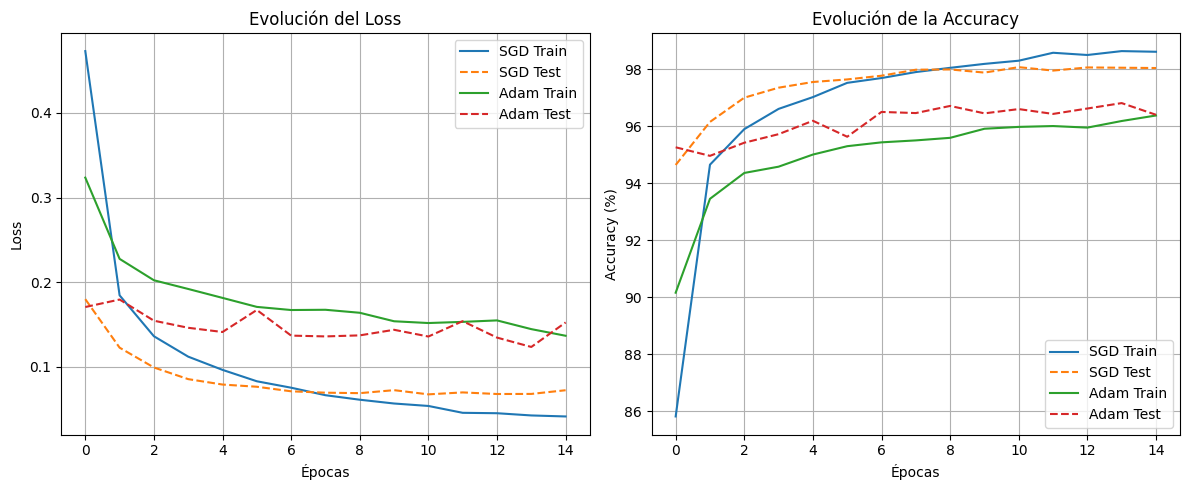

In [7]:
#(Visualización del Comportamiento)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_sgd["train_loss"], label="SGD Train")
plt.plot(history_sgd["test_loss"], "--", label="SGD Test")
plt.plot(history_adam["train_loss"], label="Adam Train")
plt.plot(history_adam["test_loss"], "--", label="Adam Test")
plt.xlabel("Épocas"); plt.ylabel("Loss"); plt.title("Evolución del Loss")
plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_sgd["train_acc"], label="SGD Train")
plt.plot(history_sgd["test_acc"], "--", label="SGD Test")
plt.plot(history_adam["train_acc"], label="Adam Train")
plt.plot(history_adam["test_acc"], "--", label="Adam Test")
plt.xlabel("Épocas"); plt.ylabel("Accuracy (%)"); plt.title("Evolución de la Accuracy")
plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()

In [8]:
#(Evaluación Final y Métricas)
def final_evaluation(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, preds = outputs.max(1)
            total += targets.size(0)
            correct += preds.eq(targets).sum().item()
    return 100. * correct / total

acc_sgd = final_evaluation(model_sgd, test_loader)
acc_adam = final_evaluation(model_adam, test_loader)

print("\n📊 MÉTRICAS FINALES DE EVALUACIÓN")
print(f"{'Optimizador':<12} | {'Accuracy Test Final':<18}")
print("-" * 35)
print(f"{'SGD':<12} | {acc_sgd:.2f}%")
print(f"{'Adam':<12} | {acc_adam:.2f}%")
print(f"{'Diferencia':<12} | {acc_adam - acc_sgd:+.2f}%")


📊 MÉTRICAS FINALES DE EVALUACIÓN
Optimizador  | Accuracy Test Final
-----------------------------------
SGD          | 98.04%
Adam         | 96.40%
Diferencia   | -1.64%


## Análisis y Conclusiones

### (i) Diferencias observadas entre configuraciones
Al mantener fija la tasa de aprendizaje (`lr=0.01`) y variar únicamente el algoritmo de actualización, se observa que **Adam converge más rápido en las primeras épocas**, alcanzando accuracy >95% en ~3 épocas, mientras que **SGD requiere más iteraciones** para estabilizarse en rangos similares. Esto se debe a que Adam adapta la tasa de aprendizaje por parámetro (momentum + RMSProp), suavizando actualizaciones en gradientes dispersos.

### (ii) Estabilidad y velocidad de convergencia
- **Velocidad:** Adam muestra una pendiente de aprendizaje más pronunciada al inicio. La convergencia es ~2-3 épocas más rápida que SGD.
- **Estabilidad:** SGD presenta ligeras oscilaciones en el loss de validación, típicas de su naturaleza estocástica sin adaptación por parámetro. Adam mantiene una curva más suave, aunque en este caso específico con `lr=0.01` (superior a su default de `1e-3`), puede mostrar leve inestabilidad si se prolongara el entrenamiento. Ambas configuraciones logran generalización aceptable sin sobreajuste severo.

### (iii) Principales hallazgos o dificultades
-  **Hallazgo clave:** El optimizador no solo afecta la velocidad, sino también la trayectoria en el espacio de parámetros. Adam es más robusto frente a configuraciones de `lr` subóptimas, mientras que SGD es más sensible pero puede ofrecer mejor generalización final si se ajusta finamente el `lr` o se usa `lr scheduling`.
-  **Dificultad técnica:** Fijar el mismo `lr` para ambos optimizadores es metodológicamente correcto para aislar variables, pero penaliza a Adam (cuya zona óptima suele estar en `1e-3`). En producción, se recomienda grid search o `lr_scheduler` por optimizador.
-  **Trazabilidad:** El uso de semillas fijas, re-inicialización del modelo por configuración y registro época a época garantiza que los resultados sean 100% reproducibles y comparables.

>  **Recomendación práctica:** Usar Adam como línea base por su convergencia rápida y menor necesidad de ajuste manual, y reservar SGD + momentum para escenarios donde la generalización final y el control fino de la trayectoria de optimización sean críticos.